# 🌍 Fine-tuning TerraMind (TiM) on Sen1Floods11
![](https://research.ibm.com/_next/image?url=https%3A%2F%2Fresearch-website-prod-cms-uploads.s3.us.cloud-object-storage.appdomain.cloud%2FScreenshot_2025_10_20_at_3_49_35_PM_9f03a58e80.png&w=1920&q=85)
*Image Source: https://research.ibm.com/blog/thinking-in-modalities-terramind*


**Goal:** Learn how to fine-tune [TerraMind](https://github.com/IBM/terramind) using the *Thinking in Modalities (TiM)* approach, where the model first generates a modality (here Sentinel-1 GRD) as an intermediate step and then uses both raw input + generated modality for downstream segmentation (flood segmentation).  
**Dataset:** [Sen1Floods11](https://github.com/cloudtostreet/Sen1Floods11).  
**Model:** TerraMind TiM (e.g., `terramind_v1_tiny_tim`).

This notebook is organized into:
1. Environment setup
2. Import libraries and define configuration
3. Explore the dataset
4. DataModule & transforms
5. Build TerraMind TiM model (S2 → generate S1GRD)
6. Trainer configuration & training
7. Quantitative evaluation
8. Visualize predictions
9. Short exercises


## 1️⃣ Environment setup

In colab:
1. Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
2. Install `TerraTorch` and other required packages

In [1]:
!pip install terratorch==1.1 gdown tensorboard

## 2️⃣ Import libraries and define configuration

We import all the necessary packages for dataset handling, model training, and visualization.

In [2]:
import os
import torch
import gdown
import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.registry import BACKBONE_REGISTRY, TERRATORCH_BACKBONE_REGISTRY, TERRATORCH_DECODER_REGISTRY, FULL_MODEL_REGISTRY

import warnings
warnings.filterwarnings('ignore')

Here, we define all the parameter used in the following steps. You can modify them based on your own case.

In [3]:
DOWNLOAD_DATASET_PATH = "./data"
DATASET_PATH = Path("sen1floods11_v1.1")
OUTPUT_PATH = Path("output/terramind_v1_tiny_tim_sen1floods11")
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_CLASSES = 2

MAX_EPOCH = 3 # Here, the value is very small to avoid using up all resources. If you want to have better result, increase it.
LEARNING_RATE = 2e-5

SEED = 42
pl.seed_everything(SEED)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


42

## 3️⃣ Sen1Floods11 Dataset

Lets start with analysing the dataset

### Step 1: Download or prepare Sen1Floods11

In [4]:
if not os.path.isfile("sen1floods11_v1.1.tar.gz"):
    gdown.download("https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS")
    !tar -xzvf sen1floods11_v1.1.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS
From (redirected): https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS&confirm=t&uuid=1427f0fa-bdb7-4840-8449-918256a5b39d
To: /content/sen1floods11_v1.1.tar.gz
100%|██████████| 1.77G/1.77G [00:27<00:00, 64.8MB/s]


sen1floods11_v1.1/
sen1floods11_v1.1/Sen1Floods11_Metadata.geojson
sen1floods11_v1.1/data/
sen1floods11_v1.1/splits/
sen1floods11_v1.1/splits/flood_test_data.txt
sen1floods11_v1.1/splits/flood_train_data.txt
sen1floods11_v1.1/splits/flood_bolivia_data.txt
sen1floods11_v1.1/splits/flood_valid_data.txt
sen1floods11_v1.1/data/LabelHand/
sen1floods11_v1.1/data/S1GRDHand/
sen1floods11_v1.1/data/S2L1CHand/
sen1floods11_v1.1/data/CopernicusDEM/
sen1floods11_v1.1/data/JRCWaterHand/
sen1floods11_v1.1/data/S1OtsuLabelHand/
sen1floods11_v1.1/data/S1OtsuLabelHand/India_747992_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/USA_170264_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/Bolivia_290290_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/Spain_7558720_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/Ghana_141910_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/Pakistan_1036366_S1OtsuLabelHand.tif
sen1floods11_v1.1/data/S1OtsuLabelHand/Parag

### Step 2: Inspect dataset folder structure

In [5]:
!ls "sen1floods11_v1.1/data"

CopernicusDEM  JRCWaterHand  LabelHand	S1GRDHand  S1OtsuLabelHand  S2L1CHand


In [6]:
!ls "sen1floods11_v1.1/data/S2L1CHand/" | head

Bolivia_103757_S2Hand.tif
Bolivia_129334_S2Hand.tif
Bolivia_195474_S2Hand.tif
Bolivia_23014_S2Hand.tif
Bolivia_233925_S2Hand.tif
Bolivia_242570_S2Hand.tif
Bolivia_290290_S2Hand.tif
Bolivia_294583_S2Hand.tif
Bolivia_312675_S2Hand.tif
Bolivia_314919_S2Hand.tif


### Step 3: Create DataLoader

We will use `terratorch.datamodules.GenericMultiModalDataModule` to prepare data.

**Important design choices**:
- We will use **S2** as raw input (Sentinel-2 L1C).
- We want **TiM**: TerraMind will generate **S1GRD** (Sentinel-1) internally as an intermediate modality; thus we only provide S2 as dataset input.
- Ensure the **band configuration** matches TerraMind pretraining: TerraMind expects S2L1C 13 bands. If your Sen1Floods11 S2 chips already provide 13 bands, good; if not, you need to pad missing bands.

In [7]:
datamodule = terratorch.datamodules.GenericMultiModalDataModule(
    task="segmentation",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    num_classes=NUM_CLASSES,

    # Define your input modalities. The names must match the keys in the following dicts.
    modalities=["S2L1C"],
    rgb_modality="S2L1C",  # Used for plotting. Defaults to the first modality if not provided.
    rgb_indices=[3,2,1],  # RGB channel positions in the rgb_modality.

    # Define data paths as dicts using the modality names as keys.
    train_data_root={
        "S2L1C": DATASET_PATH / "data/S2L1CHand",
    },
    train_label_data_root=DATASET_PATH / "data/LabelHand",
    val_data_root={
        "S2L1C": DATASET_PATH / "data/S2L1CHand",
    },
    val_label_data_root=DATASET_PATH / "data/LabelHand",
    test_data_root={
        "S2L1C": DATASET_PATH / "data/S2L1CHand",
    },
    test_label_data_root=DATASET_PATH / "data/LabelHand",

    # Define split files because all samples are saved in the same folder.
    train_split=DATASET_PATH / "splits/flood_train_data.txt",
    val_split=DATASET_PATH / "splits/flood_valid_data.txt",
    test_split=DATASET_PATH / "splits/flood_test_data.txt",

    # Define suffix, again using dicts.
    img_grep={
        "S2L1C": "*_S2Hand.tif",
    },
    label_grep="*_LabelHand.tif",

    # Define standardization values. We use the pre-training values here and providing the additional modalities is not a problem, which makes it simple to experiment with different modality combinations.
    # Alternatively, use the dataset statistics that you can generate using `terratorch compute_statistics -c config.yaml` (requires concat_bands: true for this multimodal datamodule).
    means={
      "S2L1C": [2357.089, 2137.385, 2018.788, 2082.986, 2295.651, 2854.537, 3122.849, 3040.560, 3306.481, 1473.847, 506.070, 2472.825, 1838.929],
    },
    stds={
      "S2L1C": [1624.683, 1675.806, 1557.708, 1833.702, 1823.738, 1733.977, 1732.131, 1679.732, 1727.26, 1024.687, 442.165, 1331.411, 1160.419],
    },

    # albumentations supports shared transformations and can handle multimodal inputs.
    train_transform=[
        albumentations.D4(), # Random flips and rotation
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,  # Using ToTensorV2() by default if not provided
    test_transform=None,

    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
)

# Setup train and val datasets
datamodule.setup("fit")

In [8]:
# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)

89

In [9]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

90

### Step 4. Dataset Inspection

Before training, it is important to inspect a few samples.  
We will visualize both the **input image** (RGB channels) and the **corresponding mask**.

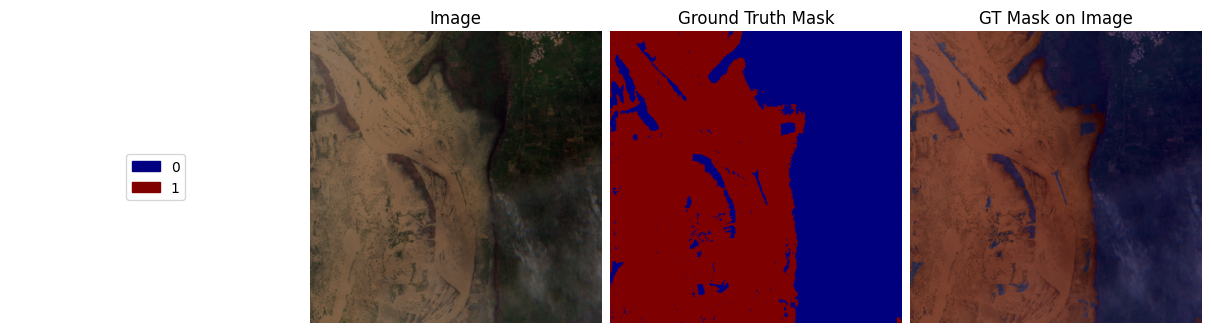

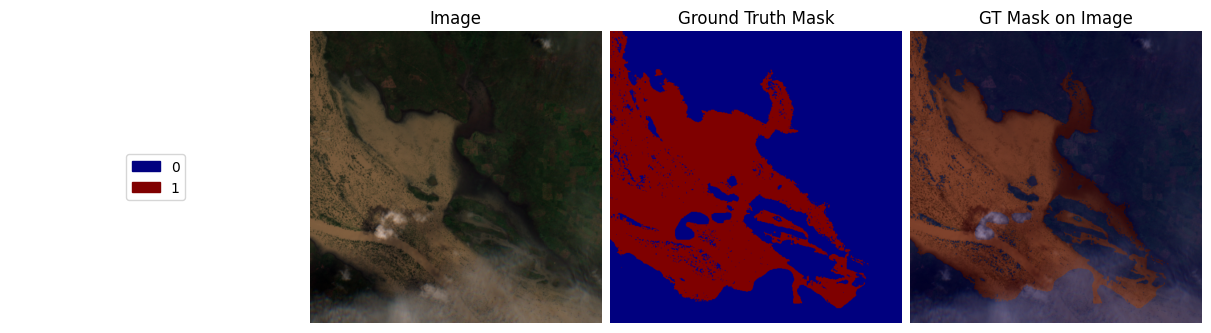

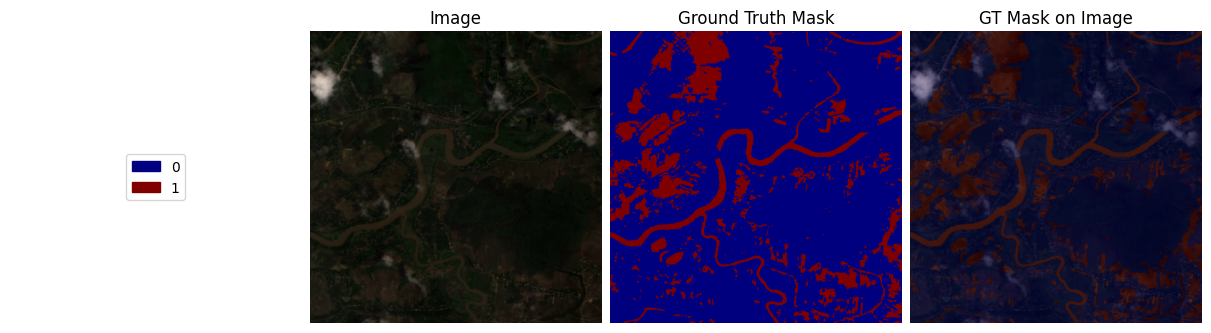

In [10]:
# plotting a few samples (The code only plots the defined `rgb_modality`)
val_dataset.plot(val_dataset[2])
plt.show()
val_dataset.plot(val_dataset[8])
plt.show()
val_dataset.plot(val_dataset[11])
plt.show()

## 4️⃣ Model Definition

We will build a TiM model that **accepts S2 only** and **predicts S1GRD as the tim modality**.

TerraMind supports modalities including `S2L2A, S1RTC, S1GRD, DEM, LULC, NDVI`

Use the `BACKBONE_REGISTRY` to construct the TiM backbone, then a `SemanticSegmentationTask` wrapper.

In [11]:
# Print all TerraMind v1 backbones.
[backbone
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if 'terramind_v1' in backbone]

['terramind_v1_base',
 'terramind_v1_base_tim',
 'terramind_v1_large',
 'terramind_v1_large_tim',
 'terramind_v1_tiny',
 'terramind_v1_tiny_tim',
 'terramind_v1_small',
 'terramind_v1_small_tim',
 'terramind_v1_tokenizer_s2l2a',
 'terramind_v1_tokenizer_s1rtc',
 'terramind_v1_tokenizer_s1grd',
 'terramind_v1_tokenizer_dem',
 'terramind_v1_tokenizer_lulc',
 'terramind_v1_tokenizer_ndvi']

In [12]:
# Build TiM backbone: S2 -> generate S1GRD internally
backbone = BACKBONE_REGISTRY.build(
    "terramind_v1_tiny_tim",   # use _tim variant
    pretrained=True,
    modalities=["S2L1C"],      # raw input S2
    tim_modalities=["S1GRD"],  # TiM will generate S1GRD as intermediate
)
print(backbone)

TerraMind_Tokenizer_S1GRD.pt:   0%|          | 0.00/1.15G [00:00<?, ?B/s]

TerraMind_v1_tiny.pt:   0%|          | 0.00/212M [00:00<?, ?B/s]

TerraMindTiM(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l1c@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=3328, out_features=192, bias=False)
    )
    (tok_sen1grd@224): ImageTokenEncoderEmbedding(
      (token_emb): Embedding(15360, 192)
    )
  )
  (sampler): GenerationSampler(
    (model): TerraMind(
      (encoder_embeddings): ModuleDict(
        (untok_sen2l1c@224): ImageEncoderEmbedding(
          (proj): Linear(in_features=3328, out_features=192, bias=False)
        )
      )
      (decoder_embeddings): ModuleDict(
        (tok_sen1grd@224): ImageTokenDecoderEmbedding(
          (token_emb): Embedding(15360, 192)
          (to_logits): Linear(in_features=192, out_features=15360, bias=False)
        )
      )
      (encoder): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm()
          (attn): Attention(
            (qkv): Linear(in_features=192, out_features=576, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
     

Now create the segmentation task using TerraTorch task API:

In [13]:
# Segmentation mask that build the model and handles training and validation steps.
model = terratorch.tasks.SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_tiny_tim", # large version: terramind_v1_large
        "backbone_pretrained": True,
        "backbone_modalities": ["S2L1C"],
        "backbone_tim_modalities": ["S1GRD"],

        # Necks
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [2, 5, 8, 11] # indices for terramind_v1_tiny, small, and base
                # "indices": [5, 11, 17, 23] # indices for terramind_v1_large
            },
            {"name": "ReshapeTokensToImage",
             "remove_cls_token": False},  # TerraMind is trained without CLS token, which neads to be specified.
            {"name": "LearnedInterpolateToPyramidal"}  # Some decoders like UNet or UperNet expect hierarchical features. Therefore, we need to learn a upsampling for the intermediate embedding layers when using a ViT like TerraMind.
        ],

        # Decoder
        "decoder": "UNetDecoder",
        "decoder_channels": [512, 256, 128, 64],

        # Head
        "head_dropout": 0.1,
        "num_classes": NUM_CLASSES,
    },

    loss="dice",  # We recommend dice for binary tasks and ce for tasks with multiple classes. Dice loss，更适合二分类的分割任务。
    optimizer="AdamW",
    lr=LEARNING_RATE,  # The optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4. You can perform hyperparameter optimization using terratorch-iterate.
    ignore_index=-1,
    freeze_backbone=True, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance.
    freeze_decoder=False,  # Should be false in most cases as the decoder is randomly initialized.
    plot_on_val=True,  # Plot predictions during validation steps
    class_names=["Others", "Water"],  # optionally define class names
)

## 5️⃣ Training Configuration

We prepare a Lightning Trainer. For a quick hands-on demo, use few epochs; for real training, increase epochs and unfreeze backbone later.

In [14]:
# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=OUTPUT_PATH / "checkpoints/",
    mode="max",
    monitor="val/mIoU", # Variable to monitor.
    filename="best-mIoU",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training. 混合精度 (16-mixed)：加速训练。
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=MAX_EPOCH, # For demos
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, pl.callbacks.RichProgressBar()],
    default_root_dir=OUTPUT_PATH,
)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


## 6️⃣ Train the Model

In [15]:
# Training
trainer.fit(model, datamodule=datamodule)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  313 M │ train │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 6.9 M                                                                                            
Non-trainable params: 306 M                                                                                        
Total params: 313 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 1319                                                                                        
Modules in eval mode: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


## 7️⃣ Model Evaluation

In [16]:
# Let's test the fine-tuned model
best_ckpt_path = OUTPUT_PATH / "checkpoints/best-mIoU.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

INFO: Restoring states from the checkpoint path at output/terramind_v1_tiny_tim_sen1floods11/checkpoints/best-mIoU.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at output/terramind_v1_tiny_tim_sen1floods11/checkpoints/best-mIoU.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at output/terramind_v1_tiny_tim_sen1floods11/checkpoints/best-mIoU.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at output/terramind_v1_tiny_tim_sen1floods11/checkpoints/best-mIoU.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric         ┃        DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy        │     0.9017542004585266     │
│ test/Class_Accuracy_Others │     0.8733809590339661     │
│ test/Class_Accuracy_Water  │     0.9301274418830872     │
│       test/F1_Score        │     0.7940464019775391     │
│      test/IoU_Others       │     0.8647437691688538     │
│       test/IoU_Water       │    0.49323517084121704     │
│    test/Pixel_Accuracy     │     0.8804782629013062     │
│         test/loss          │     0.3763789236545563     │
│         test/mIoU          │     0.6789894700050354     │
│      test/mIoU_Micro       │     0.7864770889282227     │
└────────────────────────────┴────────────────────────────┘

[{'test/loss': 0.3763789236545563,
  'test/Accuracy': 0.9017542004585266,
  'test/Class_Accuracy_Others': 0.8733809590339661,
  'test/Class_Accuracy_Water': 0.9301274418830872,
  'test/F1_Score': 0.7940464019775391,
  'test/IoU_Others': 0.8647437691688538,
  'test/IoU_Water': 0.49323517084121704,
  'test/Pixel_Accuracy': 0.8804782629013062,
  'test/mIoU': 0.6789894700050354,
  'test/mIoU_Micro': 0.7864770889282227}]

## 8️⃣ Model Prediction & Visualization

We will visualize predictions on unseen validation samples.  
The plots will show:
- Input RGB image  
- Ground truth mask  
- Model’s predicted segmentation  

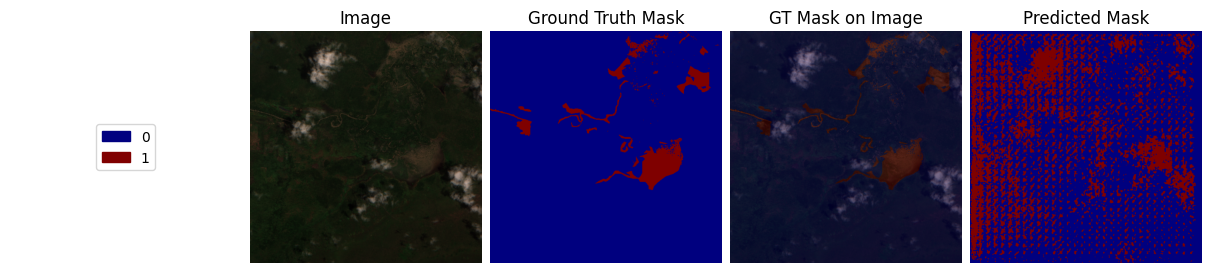

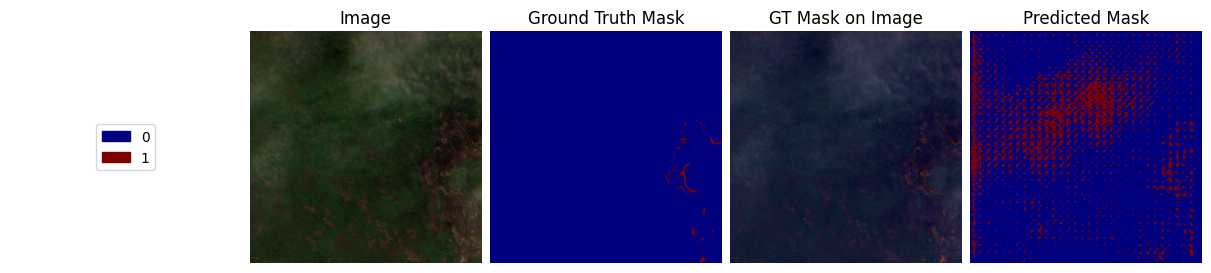

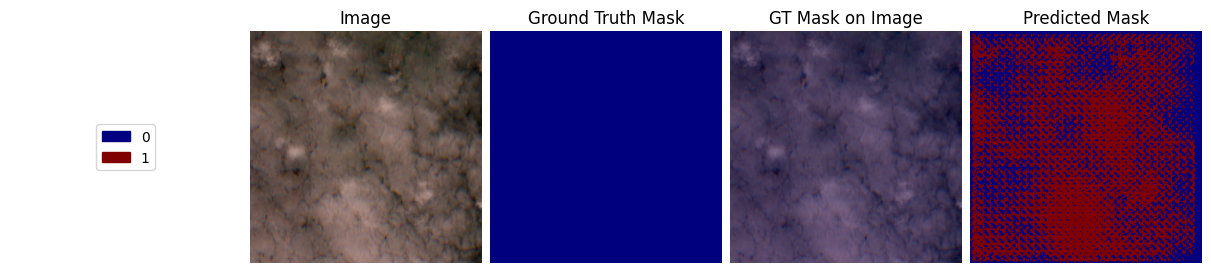

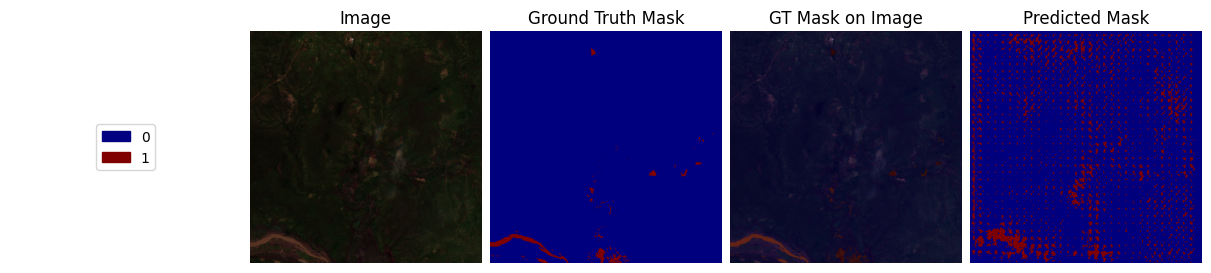

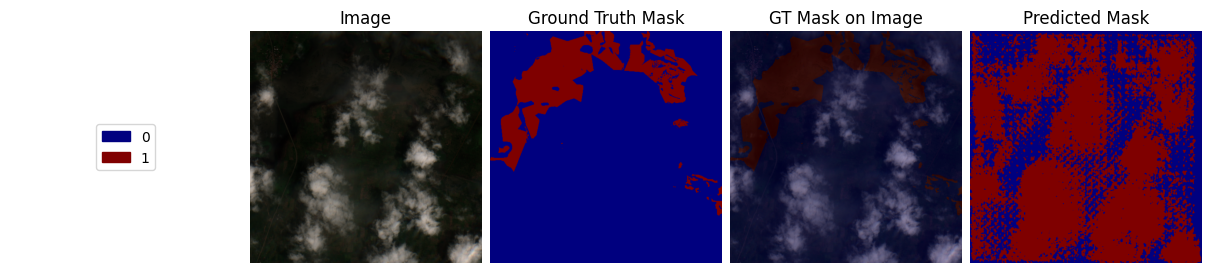

In [17]:
# Now we can use the model for predictions and plotting
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"]
    #print("image mod:", images.keys())
    for mod, value in images.items():
        images[mod] = value.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {
        "image": batch["image"]["S2L1C"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

# Note: This demo only trains for 5 epochs by default, which does not result in good predictions.

## 9️⃣ Watching the model ‘think’

To save computation, the TiM model does not generate intermediate layers as images, but instead generates tokens. However, you can decode the tokens into images for curiosity, reporting, or debugging.

In [18]:
[model for model in FULL_MODEL_REGISTRY if 'terramind_v1' in model]

['terratorch_terramind_v1_tokenizer_s2l2a',
 'terratorch_terramind_v1_tokenizer_s1rtc',
 'terratorch_terramind_v1_tokenizer_s1grd',
 'terratorch_terramind_v1_tokenizer_dem',
 'terratorch_terramind_v1_tokenizer_lulc',
 'terratorch_terramind_v1_tokenizer_ndvi',
 'terratorch_terramind_v1_base_encdec',
 'terratorch_terramind_v1_large_encdec',
 'terratorch_terramind_v1_base_generate',
 'terratorch_terramind_v1_large_generate',
 'terratorch_terramind_v1_tiny_encdec',
 'terratorch_terramind_v1_tiny_generate',
 'terratorch_terramind_v1_small_encdec',
 'terratorch_terramind_v1_small_generate']

In [19]:
import rioxarray as rxr

# Load the TerraMind generation model
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_tiny_generate', # Here, we use the tiny version.
    modalities=['S2L1C'],  # Input modalities
    output_modalities=['S1GRD'],  # TiM modalities
    pretrained=True,
    standardize=True,
)

# Load input
image_path = { # You can change this to any image you want
    'S2L1C': r"sen1floods11_v1.1/data/S2L1CHand/Bolivia_290290_S2Hand.tif",
    'S1GRD': r"sen1floods11_v1.1/data/S1GRDHand/Bolivia_290290_S1Hand.tif"
}
input = rxr.open_rasterio(image_path['S2L1C']).values
input = torch.Tensor(input).unsqueeze(0)

# Run generation
with torch.no_grad():
  generated = model(input, verbose=True, timesteps=10)

100%|██████████| 10/10 [01:33<00:00,  9.33s/it]


Now we can plot to see the generated S1GRD.

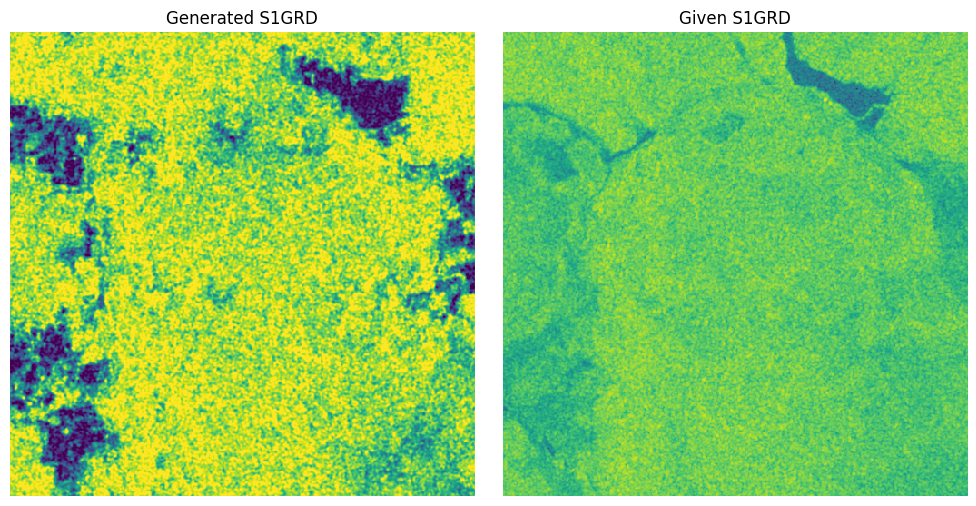

In [20]:
# Plot generated layer and given
s1grd_map = generated['S1GRD'].cpu().numpy()[0]
s1grd_ground_truth = rxr.open_rasterio(image_path['S1GRD']).values[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the generated S1GRD data
axes[0].imshow(s1grd_map[0], interpolation='nearest')
axes[0].set_title('Generated S1GRD')
axes[0].axis('off')

# Plot the ground truth S1GRD data
axes[1].imshow(s1grd_ground_truth, interpolation='nearest')
axes[1].set_title('Given S1GRD')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 🖊️ Small exercises

1. **Compare TiM vs non-TiM**
> *Task*: Train the same downstream segmentation task with:
> - (A) TerraMind tiny (non-TiM) using S2 + S1 as input
> - (B) TerraMind TiM using only S2 input (TiM generates S1 internally)
> Compare performance and GPU memory usage.

2. **Unfreeze backbone & continue training**
> *Task*: After initial training of decoder only, unfreeze the backbone (`freeze_backbone=False`) and continue training with a lower learning rate (e.g., `1e-6`) for 20–30 epochs. Report improvement in mean IoU.

3. **Try TiM with different tim modalities**
> *Task*: Use `tim_modalities=['DEM']` or `['LULC']` (if you have such data) and evaluate if generating different intermediate modalities helps downstream segmentation.